# E-Commerce Product Return Prediction & Revenue Loss Estimation
**Complete Training Notebook (Summary)**

---
This notebook covers:
- Data loading & merging (Olist dataset)
- EDA with visualisations
- Classification models: Decision Tree, Random Forest, XGBoost, DNN, LSTM, CNN
- Regression models: Linear Regression, Decision Tree, Random Forest, XGBoost, Neural Network
- SHAP explainability
- Confusion matrices, ROC-AUC curves, model comparison charts
- Artefact saving (models, scaler, TF-IDF, label encoders)

# Importing Required Libraries

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    r2_score, mean_squared_error,
    roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.feature_extraction.text import TfidfVectorizer

from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier, XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

d:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Paths & Folders

In [2]:
BASE = r"D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation"
DATA_PATH = os.path.join(BASE, "data", "raw")
MODEL_DIR = os.path.join(BASE, "models")
GRAPH_DIR = os.path.join(BASE, "notebooks", "graphs")
RESULT_DIR = os.path.join(BASE, "notebooks", "results")

for d in [MODEL_DIR, GRAPH_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

sns.set(style="whitegrid")
print("Folders ready.")
print(f"  graphs  → {GRAPH_DIR}")
print(f"  results → {RESULT_DIR}")
print(f"  models  → {MODEL_DIR}")

Folders ready.
  graphs  → D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\notebooks\graphs
  results → D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\notebooks\results
  models  → D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models


# Load & Merge Datasets

In [3]:
orders      = pd.read_csv(os.path.join(DATA_PATH, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(DATA_PATH, "olist_order_items_dataset.csv"))
payments    = pd.read_csv(os.path.join(DATA_PATH, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(DATA_PATH, "olist_order_reviews_dataset.csv"))
customers   = pd.read_csv(os.path.join(DATA_PATH, "olist_customers_dataset.csv"))
products    = pd.read_csv(os.path.join(DATA_PATH, "olist_products_dataset.csv"))

df = (orders
      .merge(order_items, on="order_id")
      .merge(payments,    on="order_id")
      .merge(reviews,     on="order_id")
      .merge(customers,   on="customer_id")
      .merge(products,    on="product_id"))

print("Merged shape:", df.shape)
df.head()

Merged shape: (118315, 36)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


# Basic EDA

## Diamention Of Dataset

In [4]:
df.shape

(118315, 36)

## All Columns

In [5]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

## Checking Data types

In [6]:
df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
order_item_id                      int64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
payment_sequential                 int64
payment_type                         str
payment_installments               int64
payment_value                    float64
review_id                            str
review_score                       int64
review_comment_title                 str
review_comment_message               str
review_creation_date                 str
review_answer_timestamp              str
customer_unique_

## Checking Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

## Unique order_ids

In [8]:
df['order_id'].nunique()

98665

## Checking Missing values

In [9]:
df.isnull().sum().sort_values(ascending=False)

review_comment_title             104230
review_comment_message            67682
order_delivered_customer_date      2588
product_name_lenght                1709
product_category_name              1709
product_photos_qty                 1709
product_description_lenght         1709
order_delivered_carrier_date       1254
product_weight_g                     20
product_length_cm                    20
product_width_cm                     20
product_height_cm                    20
order_approved_at                    15
order_status                          0
customer_id                           0
order_id                              0
order_purchase_timestamp              0
product_id                            0
order_item_id                         0
order_estimated_delivery_date         0
review_score                          0
review_id                             0
payment_value                         0
payment_installments                  0
payment_type                          0


## Negative & zero checks

In [10]:
numeric_cols = ['payment_value', 'price', 'freight_value']
for col in numeric_cols:
    print(f"{col} — negatives: {(df[col] < 0).sum()}, zeros: {(df[col] == 0).sum()}")

payment_value — negatives: 0, zeros: 6
price — negatives: 0, zeros: 0
freight_value — negatives: 0, zeros: 390


# Date Engineering

In [11]:
df['order_purchase_timestamp']      = pd.to_datetime(df['order_purchase_timestamp'],      errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')

invalid_dates = (df['order_delivered_customer_date'] < df['order_purchase_timestamp']).sum()
print("Invalid delivery dates:", invalid_dates)

df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

Invalid delivery dates: 0


## Leakage check

In [12]:
for col in ['order_status', 'review_score']:
    print(f"{col} unique values: {df[col].nunique()}")

order_status unique values: 7
review_score unique values: 5


# Fill Missing Values & Create Target Columns

## Fill non-numeric columns with "missing", numeric columns with 0

In [13]:
str_cols = df.select_dtypes(include='object').columns.tolist()
df[str_cols] = df[str_cols].fillna("missing")

num_cols_all = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols_all] = df[num_cols_all].fillna(0)

C:\Users\HP\AppData\Local\Temp\ipykernel_22616\3929405605.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns.tolist()


## Ensure review_score is numeric

In [14]:
df['review_score'] = pd.to_numeric(df['review_score'], errors='coerce').fillna(3)

## Target: is_return

In [15]:
df['is_return'] = np.where(
    (df['order_status'].isin(['canceled', 'unavailable'])) |
    (df['review_score'] <= 2),
    1, 0
)

## Target: revenue_loss

In [16]:
df['revenue_loss'] = pd.to_numeric(df['payment_value'], errors='coerce').fillna(0)

## Return distribution

In [17]:
df['is_return'].value_counts()

is_return
0    98588
1    19727
Name: count, dtype: int64

## Statistical summary of revenue_loss

In [18]:
df['revenue_loss'].describe()

count    118315.000000
mean        172.575651
std         267.104661
min           0.000000
25%          60.850000
50%         108.200000
75%         189.260000
max       13664.080000
Name: revenue_loss, dtype: float64

# EDA Plots

> All charts are saved to `notebooks/graphs/`.

In [19]:
def save_graph(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

## 1. Order status distribution

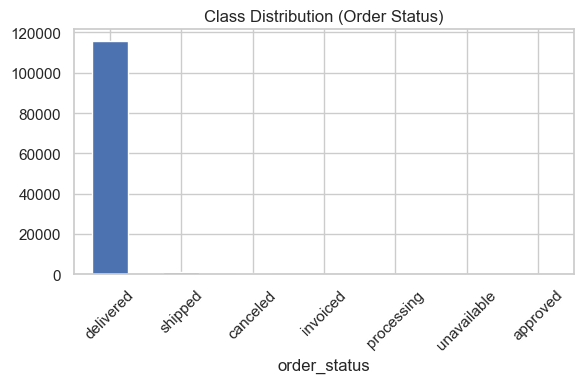

In [20]:
plt.figure(figsize=(6, 4))
df['order_status'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Order Status)")
plt.xticks(rotation=45)
save_graph("class_distribution.png")

## 2. Outlier detection

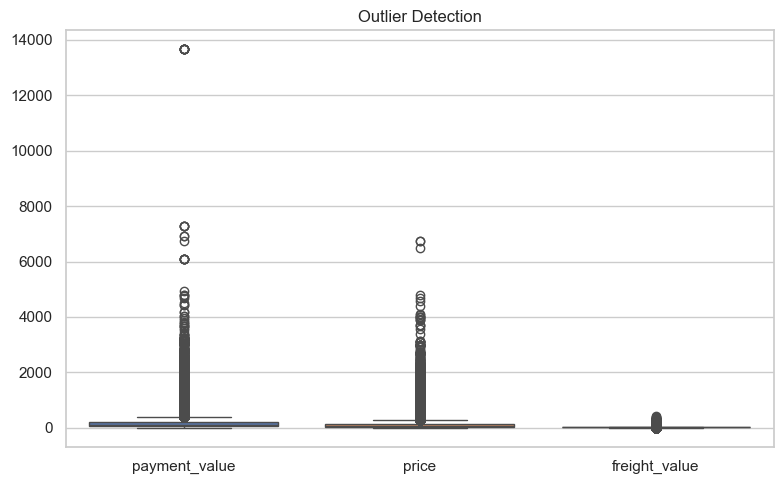

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['payment_value', 'price', 'freight_value']])
plt.title("Outlier Detection")
save_graph("outliers.png")

## 3. Target distribution

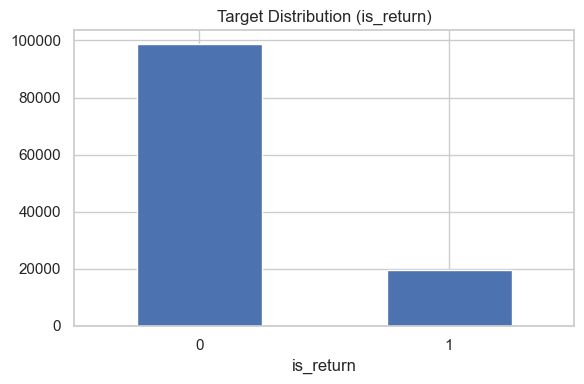

is_return
0    98588
1    19727
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(6, 4))
df['is_return'].value_counts().plot(kind='bar')
plt.title("Target Distribution (is_return)")
plt.xticks(rotation=0)
save_graph("target_distribution.png")
print(df['is_return'].value_counts())

## 4. Review score vs return

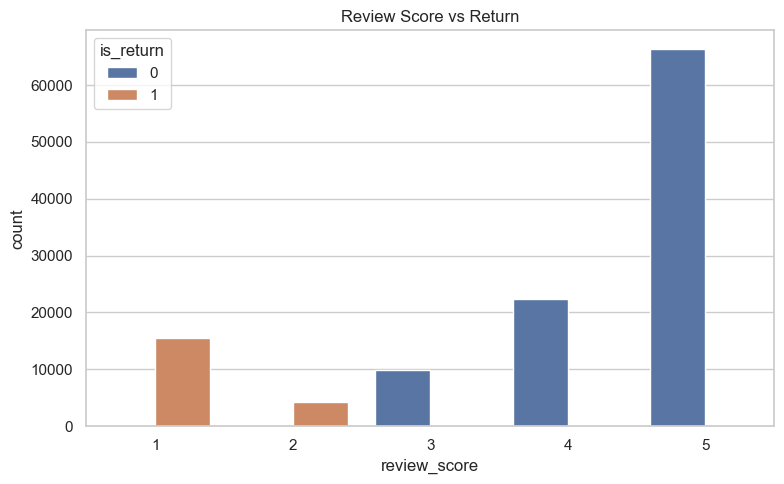

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='review_score', hue='is_return', data=df)
plt.title("Review Score vs Return")
save_graph("review_vs_return.png")

## 5. Payment value distribution

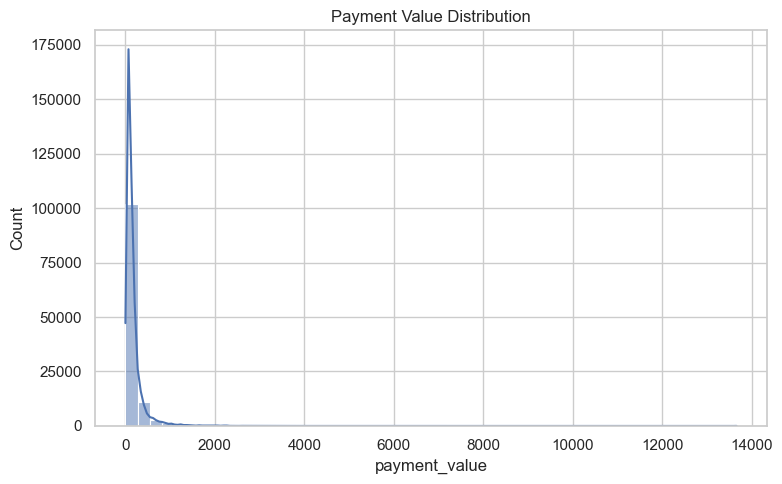

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df['payment_value'], bins=50, kde=True)
plt.title("Payment Value Distribution")
save_graph("payment_distribution.png")

## 6. Revenue loss distribution (returned orders only)

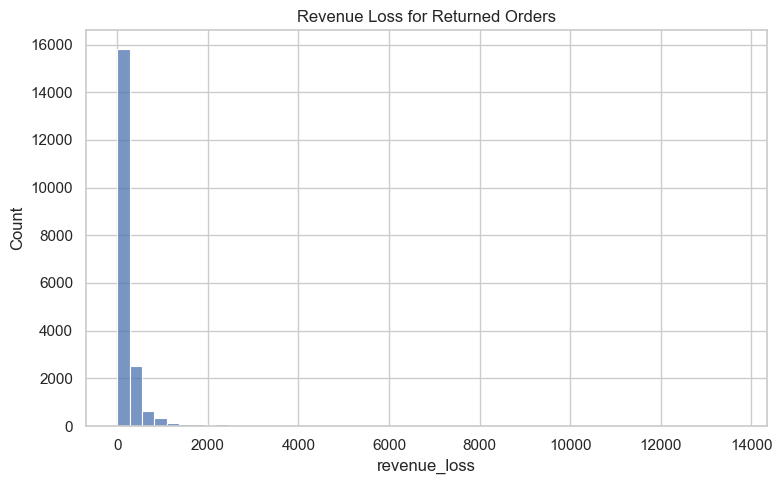

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df[df['is_return'] == 1]['revenue_loss'], bins=50)
plt.title("Revenue Loss for Returned Orders")
save_graph("revenue_loss.png")

## 7. Delivery time vs return

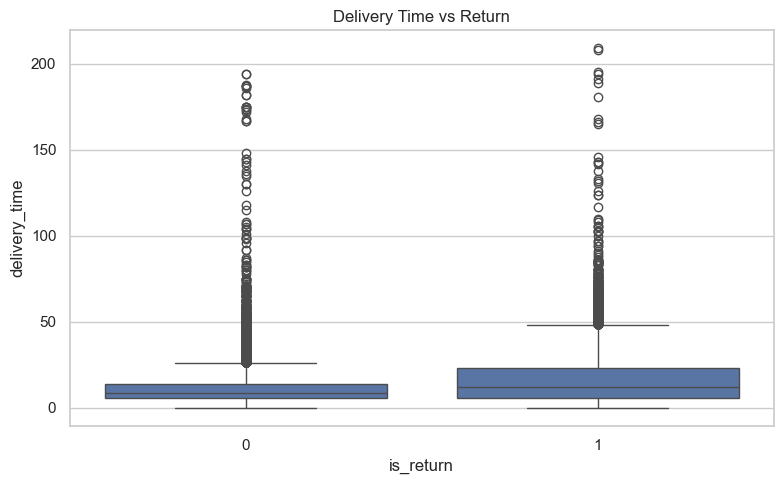

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_return', y='delivery_time', data=df)
plt.title("Delivery Time vs Return")
save_graph("delivery_vs_return.png")

## 8. Payment type distribution

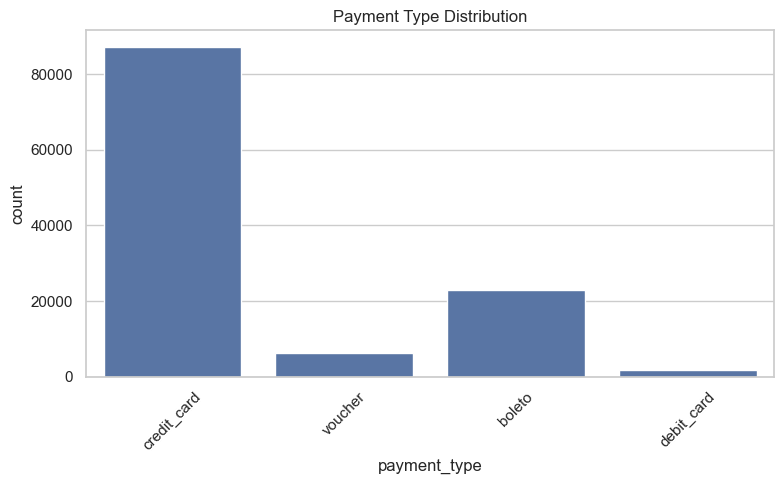

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x='payment_type', data=df)
plt.xticks(rotation=45)
plt.title("Payment Type Distribution")
save_graph("payment_type.png")

## 9. Payment type vs return

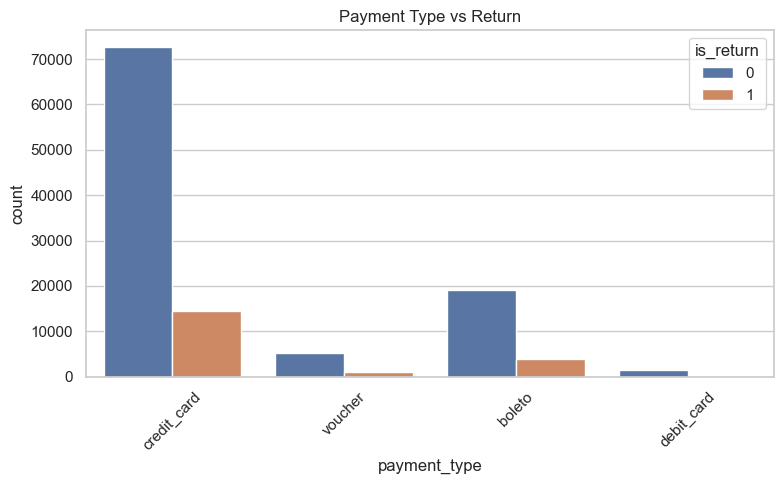

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(x='payment_type', hue='is_return', data=df)
plt.xticks(rotation=45)
plt.title("Payment Type vs Return")
save_graph("payment_vs_return.png")

## 10. Price vs return

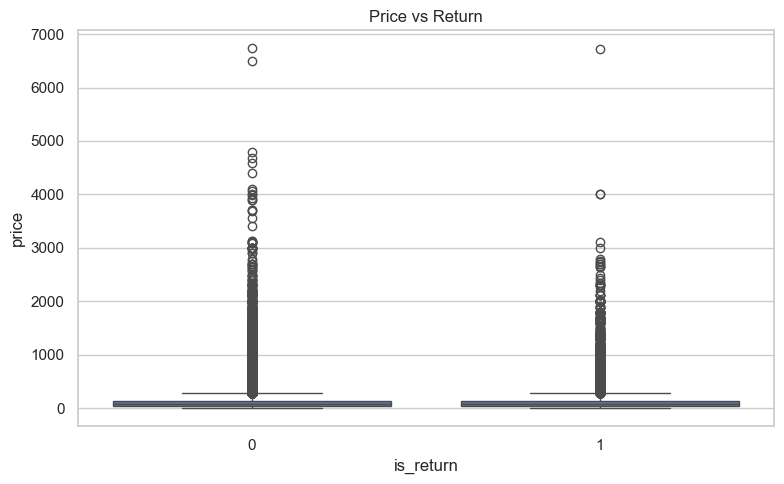

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_return', y='price', data=df)
plt.title("Price vs Return")
save_graph("price_vs_return.png")

## 11. Freight value distribution

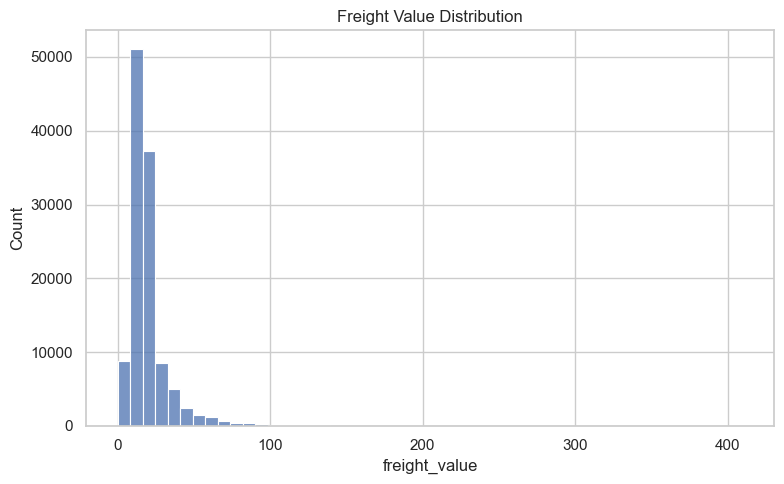

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df['freight_value'], bins=50)
plt.title("Freight Value Distribution")
save_graph("freight_value.png")

## 12. Correlation heatmap

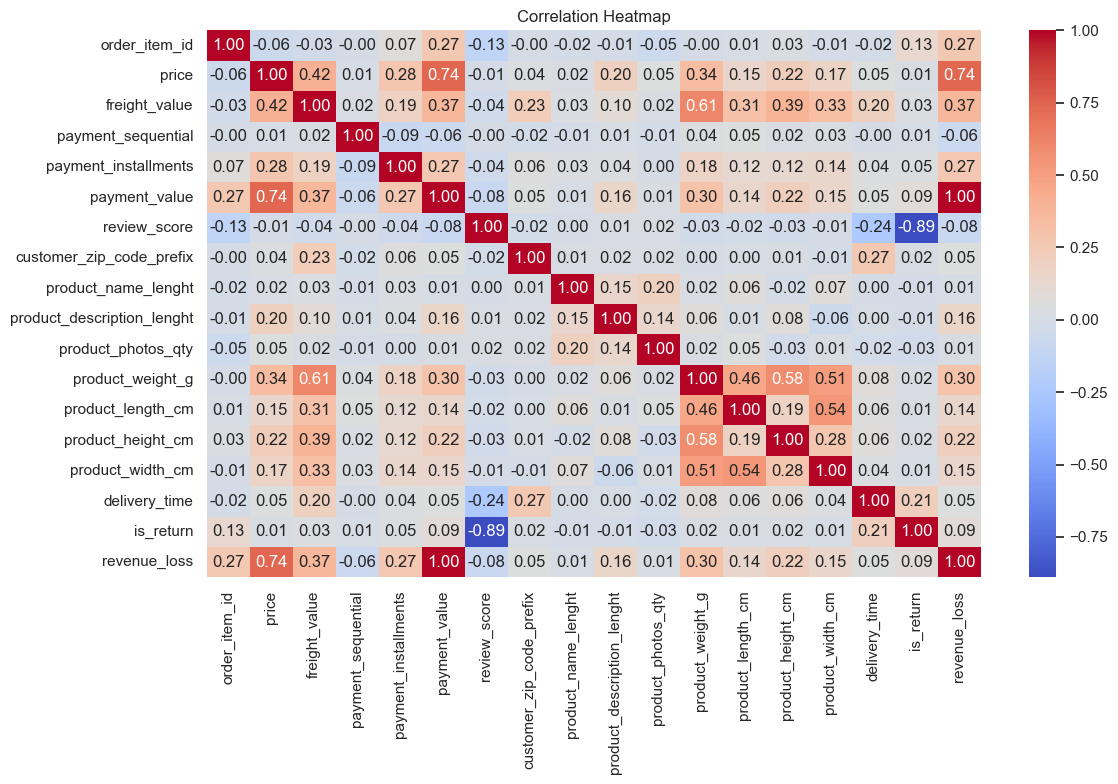

In [31]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
save_graph("correlation_heatmap.png")

## 13. Top customer states

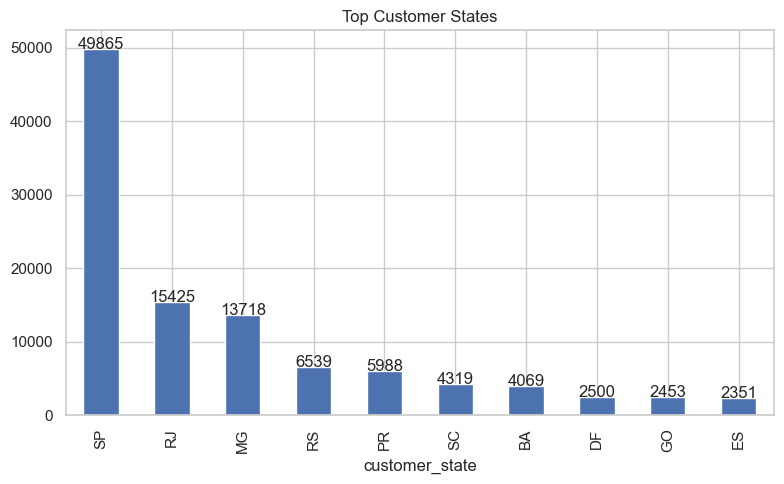

In [32]:
top_states = df['customer_state'].value_counts().head(10)
plt.figure(figsize=(8, 5))
top_states.plot(kind='bar')
for i, v in enumerate(top_states):
    plt.text(i, v, str(v), ha='center')
plt.title("Top Customer States")
save_graph("top_states.png")

## 14. Word cloud

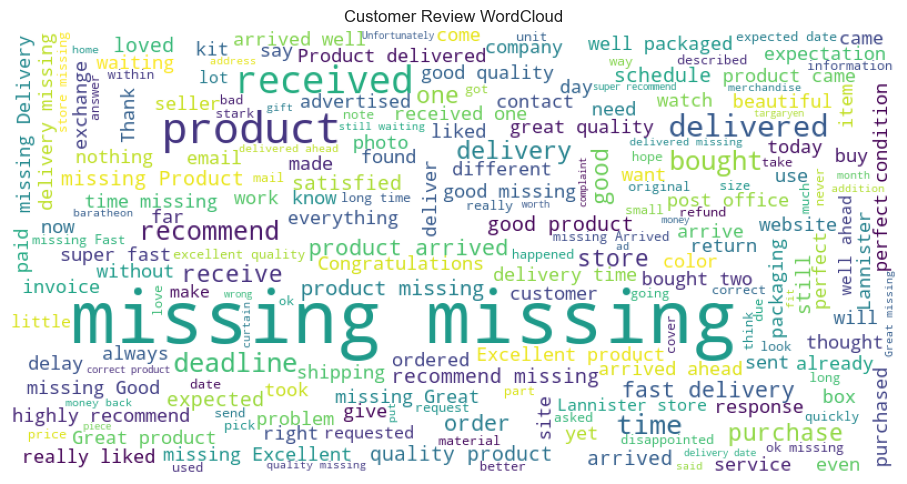

In [33]:
from wordcloud import WordCloud
text = " ".join(df['review_comment_message'].dropna().astype(str).tolist())
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.title("Customer Review WordCloud")
save_graph("wordcloud.png")

In [34]:
print("All EDA graphs saved to GRAPH_DIR.")

All EDA graphs saved to GRAPH_DIR.


# Label Encoding

In [35]:
cat_cols = ['payment_type', 'customer_state']
le_dict  = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le


## Save label encoders

In [36]:
with open(os.path.join(MODEL_DIR, "label_encoders.pkl"), "wb") as f:
    pickle.dump(le_dict, f)
print("Saved: label_encoders.pkl")

Saved: label_encoders.pkl


# TF-IDF Vectorisation

In [37]:
tfidf = TfidfVectorizer(max_features=300)
text_features = tfidf.fit_transform(df['review_comment_message'].astype(str))

## Save TF-IDF vectorizer

In [38]:
with open(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf, f)
print("Saved: tfidf_vectorizer.pkl")
print("TF-IDF matrix shape:", text_features.shape)

Saved: tfidf_vectorizer.pkl
TF-IDF matrix shape: (118315, 300)


# Feature Matrix

In [39]:
num_features = df[['payment_value', 'price', 'freight_value']].values
X = hstack([csr_matrix(num_features), text_features])   # shape (N, 303)
y_class = df['is_return']
y_reg = df['revenue_loss']

print("X shape:", X.shape)
print("y_class distribution:\n", y_class.value_counts())

X shape: (118315, 303)
y_class distribution:
 is_return
0    98588
1    19727
Name: count, dtype: int64


# SMOTE + Train/Test Split (Classification)

## SMOTE

In [40]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y_class)

## Train and Test Splitting

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (157740, 303)
X_test:  (39436, 303)
y_train: (157740,)
y_test:  (39436,)


# Scaling

In [42]:
# with_mean=False is required for sparse matrices
scaler  = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## Save scaler

In [43]:
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print("Saved: scaler.pkl")

Saved: scaler.pkl


## Dense versions needed by DNN and SHAP

In [44]:
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()
print("Dense arrays ready.")

Dense arrays ready.


# Decision Tree Classifier

In [45]:
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [46]:
y_pred_dt_cls = dt_clf.predict(X_test)
print("Decision Tree Predictions:", y_pred_dt_cls)

Decision Tree Predictions: [0 0 0 ... 1 1 0]


In [47]:
dt_acc = accuracy_score(y_test, y_pred_dt_cls)
dt_f1  = f1_score(y_test, y_pred_dt_cls)

In [48]:
print("Decision Tree Accuracy:", dt_acc)
print("Decision Tree F1:      ", dt_f1)
print(classification_report(y_test, y_pred_dt_cls))

Decision Tree Accuracy: 0.8633482097575819
Decision Tree F1:       0.8524168150075312


              precision    recall  f1-score   support

           0       0.82      0.94      0.87     19748
           1       0.92      0.79      0.85     19688

    accuracy                           0.86     39436
   macro avg       0.87      0.86      0.86     39436
weighted avg       0.87      0.86      0.86     39436



# Random Forest Classifier

In [49]:
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_cls.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [50]:
y_pred_rf_cls = rf_cls.predict(X_test)
print("Random Forest Predictions:", y_pred_rf_cls)

Random Forest Predictions: [0 0 0 ... 1 1 0]


In [51]:
rf_acc = accuracy_score(y_test, y_pred_rf_cls)
rf_f1  = f1_score(y_test, y_pred_rf_cls)

In [52]:
print("Random Forest Accuracy:", rf_acc)
print("Random Forest F1:      ", rf_f1)
print(classification_report(y_test, y_pred_rf_cls))

Random Forest Accuracy: 0.8838878182371437
Random Forest F1:       0.8759985918162861
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     19748
           1       0.94      0.82      0.88     19688

    accuracy                           0.88     39436
   macro avg       0.89      0.88      0.88     39436
weighted avg       0.89      0.88      0.88     39436



# XGBoost Classifier

In [53]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_clf.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [54]:
y_pred_xgb = xgb_clf.predict(X_test)
print("XGBoost Predictions:", y_pred_xgb)

XGBoost Predictions: [0 0 0 ... 1 1 0]


In [55]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb)

In [56]:
print("XGBoost Accuracy:", xgb_acc)
print("XGBoost F1:      ", xgb_f1)
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.89202758900497
XGBoost F1:       0.8835784983868322
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     19748
           1       0.96      0.82      0.88     19688

    accuracy                           0.89     39436
   macro avg       0.90      0.89      0.89     39436
weighted avg       0.90      0.89      0.89     39436



# DNN Classifier

In [57]:
cls_model = Sequential([
    Dense(256, activation='relu', input_dim=X_train_dense.shape[1]),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(1,   activation='sigmoid')
])

d:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
cls_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cls_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,041 (465.00 KB)

 Trainable params: 119,041 (465.00 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = cls_model.fit(
    X_train_dense, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8647 - loss: 0.3469 - val_accuracy: 0.8769 - val_loss: 0.3205
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8860 - loss: 0.2898 - val_accuracy: 0.8879 - val_loss: 0.2957
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8977 - loss: 0.2595 - val_accuracy: 0.8922 - val_loss: 0.2881
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9042 - loss: 0.2414 - val_accuracy: 0.8933 - val_loss: 0.2893
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9079 - loss: 0.2308 - val_accuracy: 0.8957 - val_loss: 0.2956
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9091 - loss: 0.2266 - val_accuracy: 0.8943 - val_loss: 0.3193
Epoch 7/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9106 - loss: 0.2223 - val_accuracy: 0.8951 - val_loss: 0.3319
Epoch 8/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9115 - loss: 0.2202 - val_acc

In [60]:
dnn_acc = cls_model.evaluate(X_test_dense, y_test, verbose=0)[1]
print("DNN Accuracy:", dnn_acc)

DNN Accuracy: 0.894385814666748


# LSTM Classifier

In [61]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['review_comment_message'].astype(str))

sequences = tokenizer.texts_to_sequences(df['review_comment_message'].astype(str))
X_text = pad_sequences(sequences, maxlen=100)

In [62]:
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_text, y_class, test_size=0.2, random_state=42)

In [63]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

d:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [64]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=256, verbose=1)
lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)[1]
print("LSTM Accuracy:", lstm_acc)

Epoch 1/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 243s 635ms/step - accuracy: 0.9017 - loss: 0.2794
Epoch 2/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 263s 710ms/step - accuracy: 0.9235 - loss: 0.2364
Epoch 3/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 256s 692ms/step - accuracy: 0.9297 - loss: 0.2241
Epoch 4/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 267s 721ms/step - accuracy: 0.9333 - loss: 0.2146
Epoch 5/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 251s 677ms/step - accuracy: 0.9371 - loss: 0.2067
LSTM Accuracy: 0.9216498136520386


# 1-D CNN Classifier

In [66]:
cnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

In [67]:
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
cnn_model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=256, verbose=1)

Epoch 1/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 108s 275ms/step - accuracy: 0.9053 - loss: 0.2734
Epoch 2/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 101s 274ms/step - accuracy: 0.9280 - loss: 0.2282
Epoch 3/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 103s 278ms/step - accuracy: 0.9375 - loss: 0.2075
Epoch 4/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 102s 275ms/step - accuracy: 0.9464 - loss: 0.1880
Epoch 5/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 100s 271ms/step - accuracy: 0.9523 - loss: 0.1726


In [69]:
cnn_acc = cnn_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)[1]

In [70]:
print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.9266787767410278


# Classification Accuracy Comparison Chart

> Saved to `notebooks/results/classification_model_results.png`

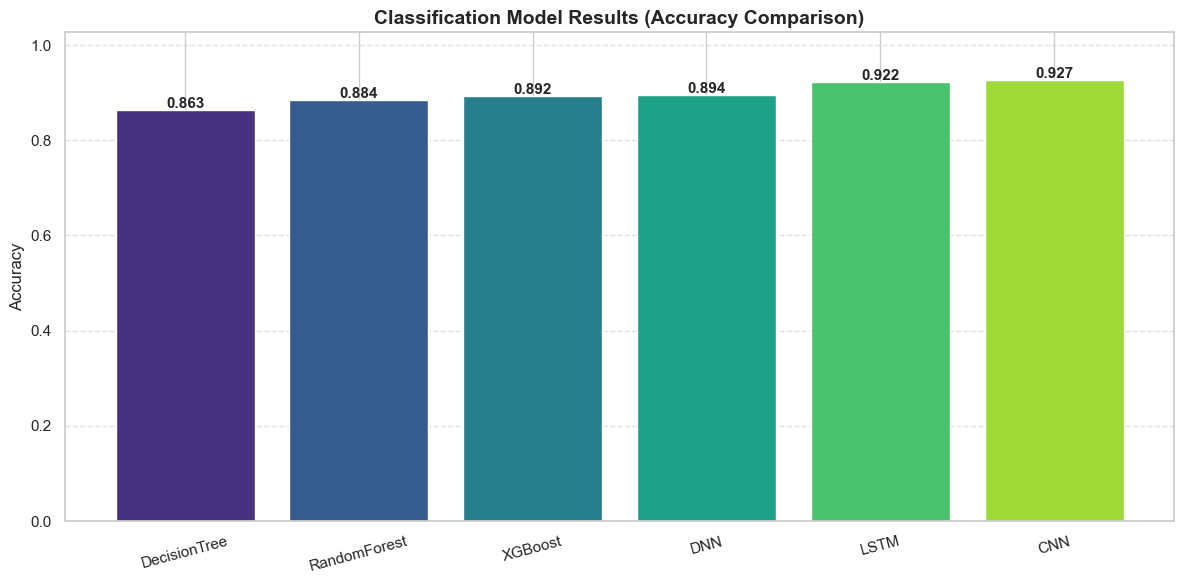

Saved: classification_model_results.png


In [71]:
models_names  = ['DecisionTree', 'RandomForest', 'XGBoost', 'DNN', 'LSTM', 'CNN']
models_scores = [dt_acc, rf_acc, xgb_acc, dnn_acc, lstm_acc, cnn_acc]

plt.figure(figsize=(12, 6))
bars = plt.bar(models_names, models_scores, color=sns.color_palette("viridis", len(models_names)))
max_score = max(models_scores)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.005,
        f'{h:.3f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.ylim(0, max_score + 0.1)
plt.title("Classification Model Results (Accuracy Comparison)", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "classification_model_results.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: classification_model_results.png")

# ROC-AUC Curve Comparison (All Classification Models)

> Saved to `notebooks/results/roc_all_models.png`

1233/1233 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
740/740 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step
740/740 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step


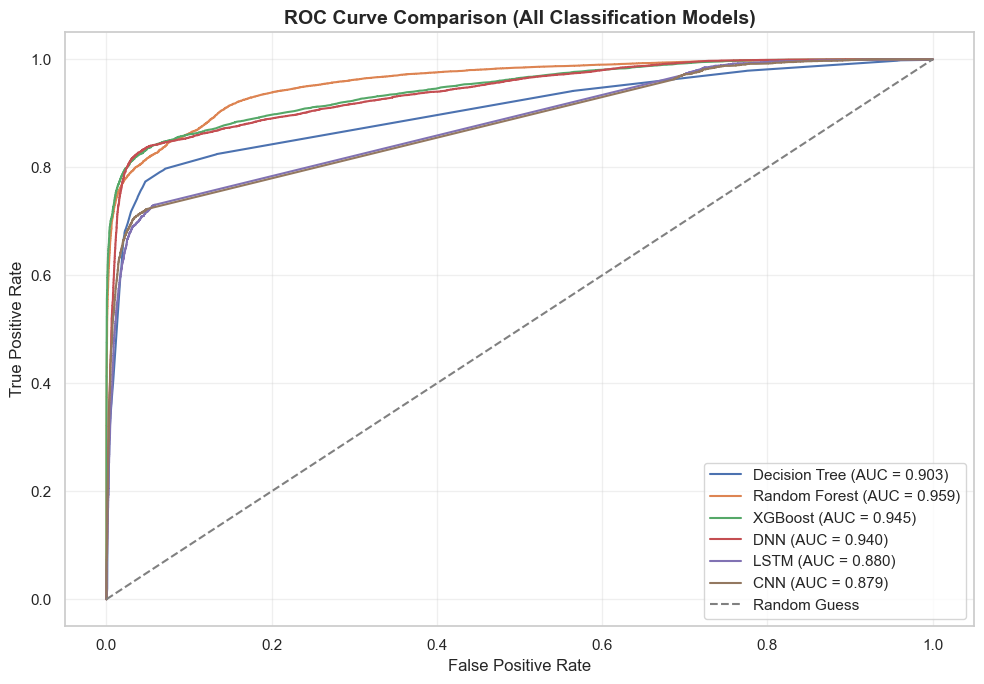

Saved: roc_all_models.png


In [72]:
plt.figure(figsize=(10, 7))

# Decision Tree
y_prob_dt  = dt_clf.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.3f})")

# Random Forest
y_prob_rf  = rf_cls.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})")

# XGBoost
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.3f})")

# DNN — must use dense array
y_prob_dnn = cls_model.predict(X_test_dense).ravel()
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, y_prob_dnn)
plt.plot(fpr_dnn, tpr_dnn, label=f"DNN (AUC = {auc(fpr_dnn, tpr_dnn):.3f})")

# LSTM
y_prob_lstm = lstm_model.predict(X_test_lstm).ravel()
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_lstm, y_prob_lstm)
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC = {auc(fpr_lstm, tpr_lstm):.3f})")

# CNN
y_prob_cnn = cnn_model.predict(X_test_lstm).ravel()
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_lstm, y_prob_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc(fpr_cnn, tpr_cnn):.3f})")

# Baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Classification Models)", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "roc_all_models.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_all_models.png")

# SHAP Explainability (XGBoost & Random Forest)

> Saved to `notebooks/results/shap_summary_xgb.png`, `shap_summary_rf.png`, `shap_bar_xgb.png`

In [73]:
X_sample_shap = X_test_dense[:1000]

# XGBoost SHAP Summary
explainer_xgb   = shap.TreeExplainer(xgb_clf)
shap_values_xgb = explainer_xgb.shap_values(X_sample_shap)

plt.figure()
shap.summary_plot(shap_values_xgb, X_sample_shap, show=False)
plt.title("SHAP Summary — XGBoost")
plt.savefig(os.path.join(RESULT_DIR, "shap_summary_xgb.png"), bbox_inches='tight', dpi=150)
plt.close()
print("Saved: shap_summary_xgb.png")

Saved: shap_summary_xgb.png


## XGBoost SHAP Bar

In [74]:
X_sample_bar    = X_test_dense[:500]
explainer_bar   = shap.TreeExplainer(xgb_clf)
shap_values_bar = explainer_bar.shap_values(X_sample_bar)

plt.figure()
shap.summary_plot(shap_values_bar, X_sample_bar, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.savefig(os.path.join(RESULT_DIR, "shap_bar_xgb.png"), bbox_inches='tight', dpi=300)
plt.close()
print("Saved: shap_bar_xgb.png")

Saved: shap_bar_xgb.png


# DNN Training Curves

> Saved to `notebooks/results/dnn_loss_curve.png` and `dnn_accuracy_curve.png`

## DNN Loss Curve

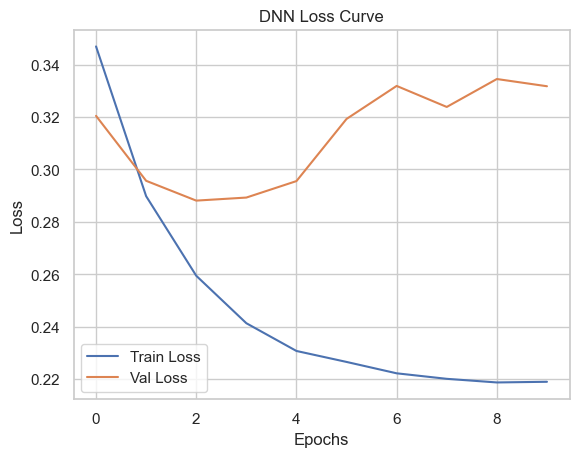

Saved: dnn_loss_curve.png


In [75]:
plt.figure()
plt.plot(history.history['loss'],                 label='Train Loss')
plt.plot(history.history.get('val_loss', []),     label='Val Loss')
plt.title("DNN Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.savefig(os.path.join(RESULT_DIR, "dnn_loss_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dnn_loss_curve.png")

## DNN Accuracy Curve

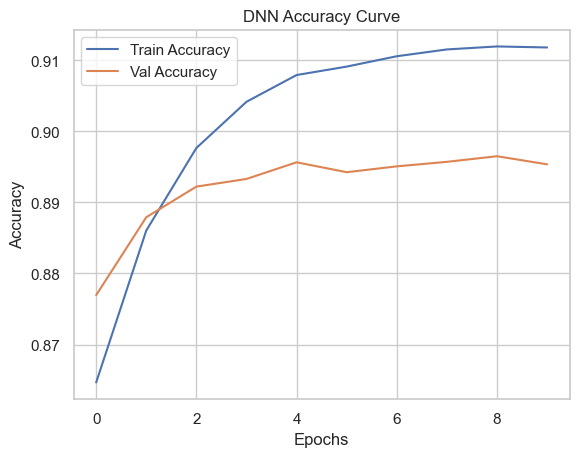

Saved: dnn_accuracy_curve.png


In [76]:
plt.figure()
plt.plot(history.history['accuracy'],              label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []),  label='Val Accuracy')
plt.title("DNN Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.savefig(os.path.join(RESULT_DIR, "dnn_accuracy_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dnn_accuracy_curve.png")

# LSTM Standalone Plots

> Saved to `notebooks/results/lstm_roc_curve.png` and `lstm_prediction_distribution.png`

## LSTM ROC

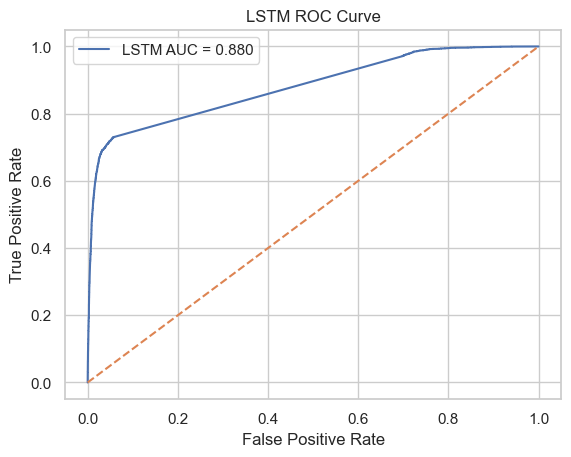

Saved: lstm_roc_curve.png


In [77]:
fpr_l, tpr_l, _ = roc_curve(y_test_lstm, y_prob_lstm)
plt.figure()
plt.plot(fpr_l, tpr_l, label=f"LSTM AUC = {auc(fpr_l, tpr_l):.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("LSTM ROC Curve")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend()
plt.savefig(os.path.join(RESULT_DIR, "lstm_roc_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_roc_curve.png")

## LSTM Prediction Distribution

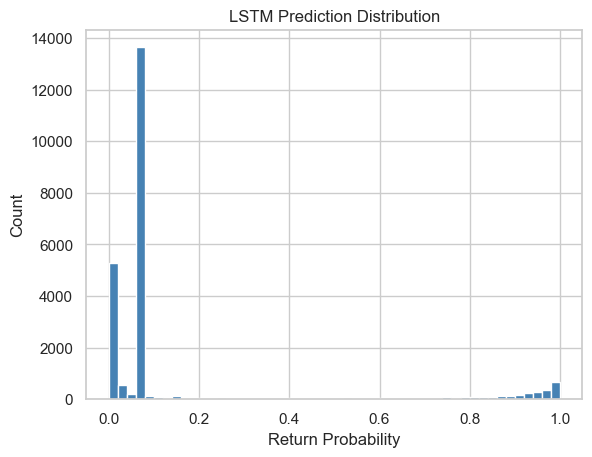

Saved: lstm_prediction_distribution.png


In [78]:
plt.figure()
plt.hist(y_prob_lstm, bins=50, color="steelblue", edgecolor="white")
plt.title("LSTM Prediction Distribution")
plt.xlabel("Return Probability"); plt.ylabel("Count")
plt.savefig(os.path.join(RESULT_DIR, "lstm_prediction_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_prediction_distribution.png")

# Confusion Matrices (All Classification Models)

> Saved to `notebooks/results/confusion_matrix_<ModelName>.png`

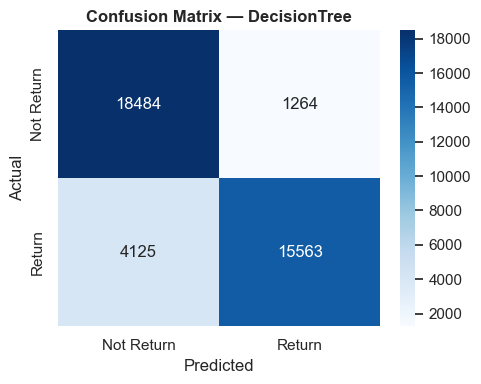

Saved: confusion_matrix_DecisionTree.png


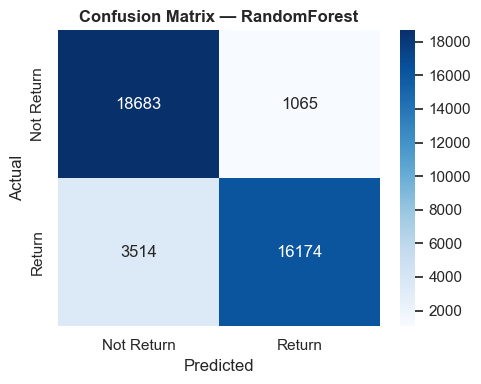

Saved: confusion_matrix_RandomForest.png


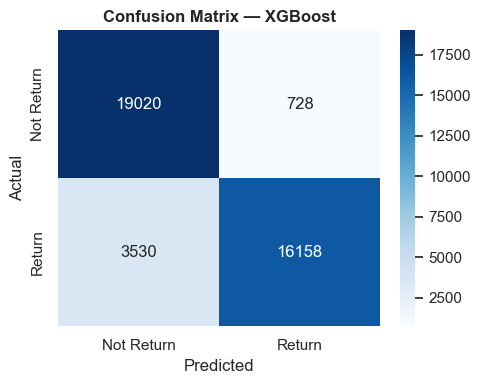

Saved: confusion_matrix_XGBoost.png


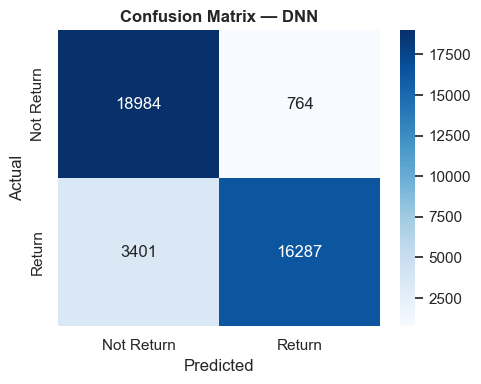

Saved: confusion_matrix_DNN.png


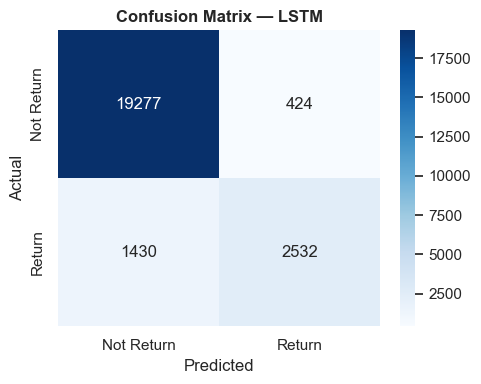

Saved: confusion_matrix_LSTM.png


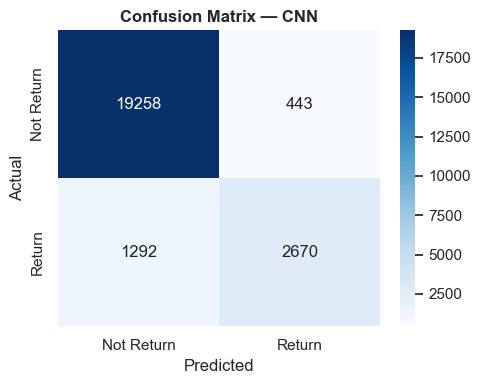

Saved: confusion_matrix_CNN.png


In [79]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Return', 'Return'],
                yticklabels=['Not Return', 'Return'])
    plt.title(f"Confusion Matrix — {model_name}", fontweight='bold')
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    save_path = os.path.join(RESULT_DIR, f"confusion_matrix_{model_name}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: confusion_matrix_{model_name}.png")

plot_confusion_matrix(y_test,      y_pred_dt_cls,                    "DecisionTree")
plot_confusion_matrix(y_test,      y_pred_rf_cls,                    "RandomForest")
plot_confusion_matrix(y_test,      y_pred_xgb,                       "XGBoost")
plot_confusion_matrix(y_test,      (y_prob_dnn  > 0.5).astype(int),  "DNN")
plot_confusion_matrix(y_test_lstm, (y_prob_lstm > 0.5).astype(int),  "LSTM")
plot_confusion_matrix(y_test_lstm, (y_prob_cnn  > 0.5).astype(int),  "CNN")

# Save All Classifiers & Identify Best

In [80]:
clf_results = {
    "DecisionTree": (dt_acc,  dt_clf),
    "RandomForest": (rf_acc,  rf_cls),
    "XGBoost":      (xgb_acc, xgb_clf),
    "DNN":          (dnn_acc, cls_model),
    "LSTM":         (lstm_acc, lstm_model),
    "CNN":          (cnn_acc,  cnn_model),
}

best_clf_name  = max(clf_results, key=lambda k: clf_results[k][0])
best_clf_score = clf_results[best_clf_name][0]
print(f"\nBest Classifier: {best_clf_name}  Accuracy: {best_clf_score:.4f}")

for name, (score, model) in clf_results.items():
    pkl_path = os.path.join(MODEL_DIR, f"best_classification_model_{name}.pkl")
    h5_path  = os.path.join(MODEL_DIR, f"best_classification_model_{name}.h5")
    try:
        with open(pkl_path, "wb") as f:
            pickle.dump(model, f)
        print(f"Saved (pkl): {pkl_path}")
    except Exception as e:
        model.save(h5_path)
        print(f"Saved (h5):  {h5_path}  [{e}]")


Best Classifier: CNN  Accuracy: 0.9267
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_classification_model_DecisionTree.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_classification_model_RandomForest.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_classification_model_XGBoost.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_classification_model_DNN.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_classification_model_LSTM.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_classification_model_CNN.pkl


# Regression Models (Revenue Loss Estimation)

In [81]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

## Apply same scaler (already fitted)

In [82]:
X_reg_train_sc = scaler.transform(X_reg_train)
X_reg_test_sc  = scaler.transform(X_reg_test)

In [83]:
X_reg_train_dense = X_reg_train_sc.toarray()
X_reg_test_dense  = X_reg_test_sc.toarray()

## 1. Linear Regression

In [84]:
lr = LinearRegression()
lr.fit(X_reg_train_dense, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
y_pred_lr = lr.predict(X_reg_test_dense)

In [86]:
lr_r2   = r2_score(y_reg_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
print(f"Linear Regression  R²={lr_r2:.4f}  RMSE={lr_rmse:.2f}")

Linear Regression  R²=1.0000  RMSE=0.00


## 2. Decision Tree Regressor

In [87]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_reg_train_sc, y_reg_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [88]:
y_pred_dt_reg = dt_reg.predict(X_reg_test_sc)

In [89]:
dt_r2   = r2_score(y_reg_test, y_pred_dt_reg)
dt_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_dt_reg))
print(f"Decision Tree      R²={dt_r2:.4f}  RMSE={dt_rmse:.2f}")

Decision Tree      R²=1.0000  RMSE=0.87


## 3. Random Forest Regressor

In [90]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg_train_sc, y_reg_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [91]:
y_pred_rf_reg = rf_reg.predict(X_reg_test_sc)

In [92]:
rf_r2   = r2_score(y_reg_test, y_pred_rf_reg)
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg))
print(f"Random Forest      R²={rf_r2:.4f}  RMSE={rf_rmse:.2f}")

Random Forest      R²=1.0000  RMSE=0.70


## 4. XGBoost Regressor

In [93]:
xgb_reg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42)
xgb_reg.fit(X_reg_train_sc, y_reg_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [94]:
y_pred_xgb_reg = xgb_reg.predict(X_reg_test_sc)

In [95]:
xgb_r2   = r2_score(y_reg_test, y_pred_xgb_reg)
xgb_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb_reg))
print(f"XGBoost            R²={xgb_r2:.4f}  RMSE={xgb_rmse:.2f}")

XGBoost            R²=0.9784  RMSE=37.53


## 5. Neural Network Regressor

In [96]:
nn_reg = Sequential([
    Dense(256, activation='relu', input_dim=X_reg_train_dense.shape[1]),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(1)
])

d:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
nn_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])
nn_reg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,041 (465.00 KB)

 Trainable params: 119,041 (465.00 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
nn_reg.fit(X_reg_train_dense, y_reg_train, epochs=10, batch_size=256, verbose=1)

Epoch 1/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 26943.4941 - mae: 72.1326 
Epoch 2/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 1123.0905 - mae: 17.8657
Epoch 3/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 517.8987 - mae: 12.0882
Epoch 4/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 345.5370 - mae: 10.1026
Epoch 5/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 265.7242 - mae: 8.8131
Epoch 6/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 217.3866 - mae: 8.1772
Epoch 7/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 194.3610 - mae: 7.6616
Epoch 8/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 173.3189 - mae: 7.3772
Epoch 9/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 165.3052 - mae: 7.0639
Epoch 10/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 154.9639 - mae: 6.8827


In [99]:
nn_pred = nn_reg.predict(X_reg_test_dense)
nn_r2   = r2_score(y_reg_test, nn_pred)
print(f"Neural Network     R²={nn_r2:.4f}")

740/740 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Neural Network     R²=0.9960


## Cell 27 — Regression Model Comparison Chart

> Saved to `notebooks/results/final_regression_comparison.png`

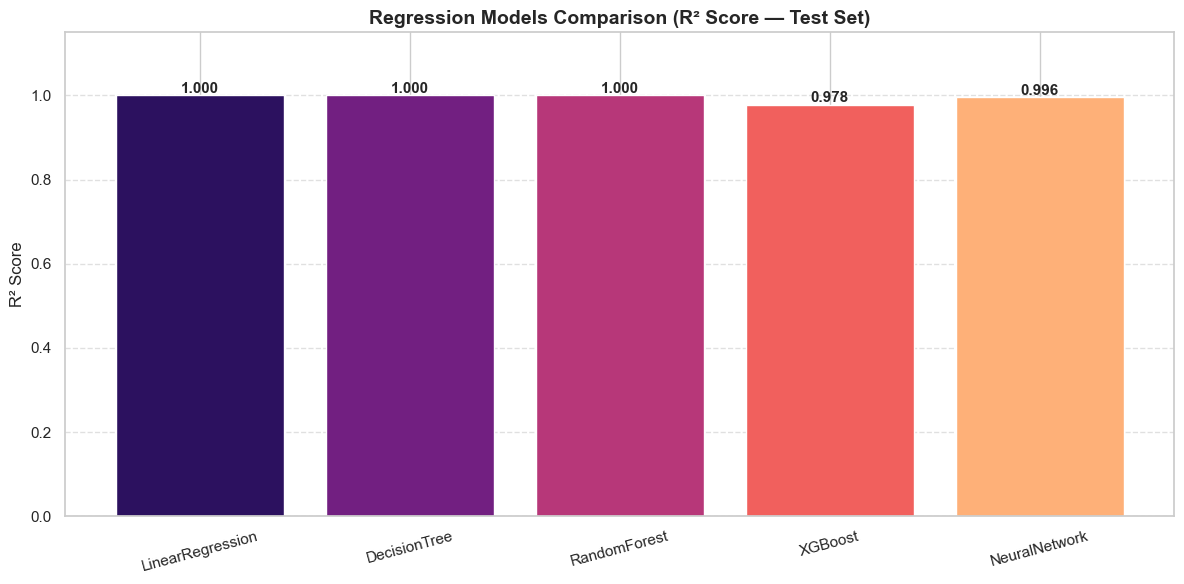

Saved: final_regression_comparison.png


In [100]:
reg_model_names  = ['LinearRegression', 'DecisionTree', 'RandomForest', 'XGBoost', 'NeuralNetwork']
reg_model_scores = [lr_r2, dt_r2, rf_r2, xgb_r2, nn_r2]

plt.figure(figsize=(12, 6))
bars = plt.bar(reg_model_names, reg_model_scores,
               color=sns.color_palette("magma", len(reg_model_names)))
max_r2 = max(reg_model_scores)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.005,
        f'{h:.3f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.ylim(0, max_r2 + 0.15)
plt.title("Regression Models Comparison (R² Score — Test Set)", fontsize=14, fontweight='bold')
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "final_regression_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_regression_comparison.png")

## Cell 28 — Save All Regressors & Identify Best

In [101]:
reg_results = {
    "LinearRegression": (lr_r2,   lr),
    "DecisionTree":     (dt_r2,   dt_reg),
    "RandomForest":     (rf_r2,   rf_reg),
    "XGBoost":          (xgb_r2,  xgb_reg),
    "NeuralNetwork":    (nn_r2,   nn_reg),
}

best_reg_name  = max(reg_results, key=lambda k: reg_results[k][0])
best_reg_score = reg_results[best_reg_name][0]
print(f"\nBest Regressor: {best_reg_name}  R²: {best_reg_score:.4f}")


Best Regressor: LinearRegression  R²: 1.0000


In [102]:
for name, (score, model) in reg_results.items():
    pkl_path = os.path.join(MODEL_DIR, f"best_model_{name}.pkl")
    h5_path  = os.path.join(MODEL_DIR, f"best_model_{name}.h5")
    try:
        with open(pkl_path, "wb") as f:
            pickle.dump(model, f)
        print(f"Saved (pkl): {pkl_path}")
    except Exception as e:
        model.save(h5_path)
        print(f"Saved (h5):  {h5_path}  [{e}]")

Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_model_LinearRegression.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_model_DecisionTree.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_model_RandomForest.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_model_XGBoost.pkl
Saved (pkl): D:\Data Science (Atomcamp)\E-Commerce Product Return Prediction & Revenue Loss Estimation\models\best_model_NeuralNetwork.pkl
